# EVT/POT Calibration Workflow (GloFAS v4 → Virtual Gauges → Poisson λ)

This notebook provides an **end-to-end, operator-friendly calibration workflow** for riverine flood triggers:

1. **Select impact units (HydroBASINS L12)**
   - **Mode A** (municipality AOI): population-weighted centroid (WorldPop) + 5 km geodesic buffer, clipped to ADM3
   - **Mode B** (context basin): select all L12 inside a configured context basin polygon (e.g., L7)
2. **Assign virtual gauges**
   - One representative point per L12: **L12 pour point → nearest GloFAS grid cell**
   - **Collisions are expected** (multiple L12 → same GloFAS cell). We calibrate **per unique cell**.
3. **GRIB → daily discharge time series** (cached)
4. **POT/EVT extraction** using `pyextremes` + run-length declustering
5. **Poisson frequency λ** per unique virtual gauge

> Locked decisions: all geometry remains in **EPSG:4326 (WGS84)** and we use **GloFAS historical/reanalysis v4 consolidated discharge GRIBs**.


## 0) Setup (robust imports, repo root, dependency checks)

This cell makes the notebook robust to:
- `ModuleNotFoundError` when running from different working directories
- Windows path handling (use raw strings)

If anything fails here, fix it before proceeding.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional interactivity
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
    print('HAS_WIDGETS:', HAS_WIDGETS)
except Exception:
    HAS_WIDGETS = False
    print('HAS_WIDGETS:', HAS_WIDGETS)

# --- Find repo root and add src/ to sys.path ---
try:
    from philflood.utils.paths import find_repo_root, ensure_src_on_path
except Exception:
    # Fallback: assume this notebook lives under <repo>/notebooks/
    def find_repo_root(start=None):
        p = Path.cwd().resolve() if start is None else Path(start).resolve()
        for parent in (p, *p.parents):
            if (parent / 'src').exists():
                return parent
        raise RuntimeError('Could not find repo root; set REPO_ROOT manually')

    def ensure_src_on_path(repo_root):
        repo_root = Path(repo_root).resolve()
        src = repo_root / 'src'
        if str(src) not in sys.path:
            sys.path.insert(0, str(src))
        return src

REPO_ROOT = find_repo_root()
SRC_PATH = ensure_src_on_path(REPO_ROOT)
print('REPO_ROOT:', REPO_ROOT)
print('SRC_PATH :', SRC_PATH)

# Now imports from src/
from philflood.config.basin import load_basin_config
from philflood.geo.worldpop import population_weighted_centroid
from philflood.geo.aoi import build_municipality_aoi
from philflood.geo.hydrobasins import read_vector, select_context_polygon, select_l12_by_geometry, get_id_field
from philflood.adapters.glofas_grib_v4 import (
    discover_grib_year_files,
    open_grib_dataset,
    nearest_grid_cell,
    load_or_build_gauge_timeseries,
)
from philflood.qc.timeseries import qc_daily_series, qc_summary_dict
from philflood.calibration.evt_pot import pot_extract, fit_gpd_to_pot

print('Core imports OK')


HAS_WIDGETS: True
REPO_ROOT: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL
SRC_PATH : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\src
Core imports OK


## 1) Operator inputs (edit here)

Set paths and mode switches below. The notebook will validate and **fail fast** if anything is missing.

**Locked data paths (examples):**
- WorldPop raster: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif`
- ADM3 municipalities: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\admin\phl_cod_ab\phl_adm3.geojson`
- HydroBASINS L12 polygons: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_au_lev01-12_v1c\hybas_au_lev12_v1c.shp`
- HydroBASINS L12 pour points: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_pour_lev01-12_v1_shp\hybas_pour_lev12_v1.shp`
- GloFAS v4 GRIB root: `C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131`

> Tip: use raw strings `r"..."` on Windows.


In [2]:
# --- Mode toggle (locked requirement) ---
USE_MUNI_AOI = True  # True = municipality AOI mode, False = context basin mode

# --- Setup logging for better diagnostics ---
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
# Set DEBUG for philflood modules
logging.getLogger('philflood').setLevel(logging.DEBUG)

# --- Municipality AOI mode inputs ---
adm3_ids = [
    # Example: "PHLxxxx". Must match adm3_id in the ADM3 GeoJSON.
    # Fill with one or more municipalities.
    "30758251B93060635103686",  # Gattaran, Cagayan

]
aoi_buffer_km = 5

# --- Context basin mode inputs (legacy YAML) ---
basin_cfg_relpath = r"ops\configs\basins\Cagayan_01.yaml"  # repo-relative (legacy)
context_select_mode = "within"  # within|intersects

# --- Locked data paths (set these to your local repo paths) ---
worldpop_raster = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif")
adm3_geojson = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\admin\phl_cod_ab\phl_adm3.geojson")
hybas_l12_shp = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_au_lev01-12_v1c\hybas_au_lev12_v1c.shp")
hybas_pour_l12_shp = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_pour_lev01-12_v1_shp\hybas_pour_lev12_v1.shp")

glofas_grib_root = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131")

# --- Calibration defaults ---
run_tag = "2026-01-19_calib"  # used in output folder names
analyst_name = "David"

run_length_days = 5
candidate_quantiles = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

# Optional: explicitly set discharge variable name in GRIB (leave None to auto-detect)
discharge_var = None

# --- Processed output root (repo-relative) ---
processed_root = REPO_ROOT / "data" / "processed"

# Print resolved paths for transparency
print("USE_MUNI_AOI:", USE_MUNI_AOI)
print("worldpop_raster:", worldpop_raster)
print("adm3_geojson  :", adm3_geojson)
print("hybas_l12_shp :", hybas_l12_shp)
print("pour points   :", hybas_pour_l12_shp)
print("glofas_grib_root:", glofas_grib_root)
print("processed_root:", processed_root)


USE_MUNI_AOI: True
worldpop_raster: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif
adm3_geojson  : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\admin\phl_cod_ab\phl_adm3.geojson
hybas_l12_shp : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_au_lev01-12_v1c\hybas_au_lev12_v1c.shp
pour points   : C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_pour_lev01-12_v1_shp\hybas_pour_lev12_v1.shp
glofas_grib_root: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131
processed_root: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed


In [3]:
# --- Year selector for debugging (test individual years) ---
# Set to None to process all available years, or provide a list like [2014] to test specific years
# USAGE: To test if 2014 is problematic, set: SELECTED_YEARS = [2014]
#        To test a range like 2010-2015: SELECTED_YEARS = list(range(2010, 2016))
#        To process all years: SELECTED_YEARS = None
SELECTED_YEARS = list(range(2010, 2016))  # Examples: None (all), [2014], [2010, 2011, 2012], list(range(2010, 2016))

# Dynamic year selector (if you have ipywidgets)
if HAS_WIDGETS:
    print("Year Selection Options:")
    print("  - None: Process all available years")
    print("  - List: e.g., [2014] to test problematic years")
    print("  - Range: list(range(2010, 2016)) for 2010-2015")
    print(f"Current selection: {SELECTED_YEARS}")


Year Selection Options:
  - None: Process all available years
  - List: e.g., [2014] to test problematic years
  - Range: list(range(2010, 2016)) for 2010-2015
Current selection: [2010, 2011, 2012, 2013, 2014, 2015]


## 2) Validate inputs (fail fast)

We stop early if any required file is missing. This prevents silent downstream failures.


In [4]:
def _assert_exists(p: Path, label: str):
    if not p.exists():
        raise FileNotFoundError(f"{label} not found: {p}")

_assert_exists(worldpop_raster, "WorldPop raster")
_assert_exists(adm3_geojson, "ADM3 GeoJSON")
_assert_exists(hybas_l12_shp, "HydroBASINS L12 polygons")
_assert_exists(hybas_pour_l12_shp, "HydroBASINS L12 pour points")
_assert_exists(glofas_grib_root, "GloFAS GRIB root")

# Context basin YAML is only required in context mode
if not USE_MUNI_AOI:
    basin_cfg_path = (REPO_ROOT / Path(basin_cfg_relpath)).resolve()
    _assert_exists(basin_cfg_path, "Legacy basin config YAML")

print("All required inputs exist.")


All required inputs exist.


## 3) Load vectors and (optionally) context basin config


In [5]:
import geopandas as gpd

adm3_gdf = read_vector(adm3_geojson)
l12_gdf = read_vector(hybas_l12_shp)
pour_gdf = read_vector(hybas_pour_l12_shp)

print("ADM3 rows:", len(adm3_gdf))
print("L12 rows :", len(l12_gdf))
print("Pour rows:", len(pour_gdf))

# Identify IDs
adm3_id_field = "adm3_id" if "adm3_id" in adm3_gdf.columns else None
if adm3_id_field is None:
    raise KeyError(f"ADM3 GeoJSON must include 'adm3_id'. Found columns: {list(adm3_gdf.columns)}")

l12_id_field = get_id_field(l12_gdf)
pour_id_field = get_id_field(pour_gdf)

print("ADM3 id field:", adm3_id_field)
print("L12  id field:", l12_id_field)
print("Pour id field:", pour_id_field)

basin_cfg = None
context_gdf = None
context_geom = None
if not USE_MUNI_AOI:
    basin_cfg = load_basin_config(basin_cfg_path)
    print("Loaded basin config:", basin_cfg.basin_id)
    print("Context hydrobasins level/id:", basin_cfg.hydrobasins_level, basin_cfg.hydrobasins_id)
    # Load the context basin polygons for that level (user should set path if needed)
    # For now, we re-use the L12 shapefile only when level=12; otherwise you must point to the appropriate level file.
    if basin_cfg.hydrobasins_level == 12:
        context_gdf = l12_gdf
    else:
        # Operator: set this to the correct HydroBASINS level shapefile for your context
        raise RuntimeError(
            "Context basin mode requires the HydroBASINS polygon file for the configured level. "
            "Set a path to hybas_au_levXX_v1c.shp and load it here."
        )



ADM3 rows: 1647
L12 rows : 83929
Pour rows: 5271492
ADM3 id field: adm3_id
L12  id field: HYBAS_ID
Pour id field: HYBAS_ID


## 4) Select L12 impact units

Two modes:

### Mode A: Municipality AOI
- For each selected municipality:
  - population-weighted centroid (WorldPop)
  - AOI = geodesic buffer(5 km) clipped to municipality polygon
  - select all intersecting L12 polygons

### Mode B: Context basin
- Select all L12 polygons inside the context basin geometry


In [6]:
selected_l12 = None
muni_aoi_records = []
aoi_geoms = []

if USE_MUNI_AOI:
    if not adm3_ids:
        raise ValueError("USE_MUNI_AOI=True requires adm3_ids to be provided")

    for mid in adm3_ids:
        muni = adm3_gdf[adm3_gdf[adm3_id_field] == mid]
        if len(muni) != 1:
            raise ValueError(f"Expected exactly 1 municipality for adm3_id={mid}, found {len(muni)}")
        muni_geom = muni.geometry.values[0]

        # Population-weighted centroid (fails loudly if no population)
        wc = population_weighted_centroid(muni_geom, worldpop_raster)
        aoi = build_municipality_aoi(muni_geom, wc.point, buffer_km=aoi_buffer_km)

        aoi_geoms.append(aoi.aoi_polygon)

        sel = select_l12_by_geometry(l12_gdf, aoi.aoi_polygon, mode="intersects")
        muni_aoi_records.append({
            "adm3_id": mid,
            "centroid_lon": float(wc.point.x),
            "centroid_lat": float(wc.point.y),
            "total_population": float(wc.total_population),
            "valid_pixel_count": int(wc.valid_pixel_count),
            "n_l12_selected": int(len(sel)),
            "l12_ids": sel[l12_id_field].astype(int).tolist(),
        })

    # Union selection across municipalities
    all_ids = sorted({i for r in muni_aoi_records for i in r["l12_ids"]})
    selected_l12 = l12_gdf[l12_gdf[l12_id_field].astype(int).isin(all_ids)].copy()
    print("Municipality AOI records using spatial:", muni_aoi_records)

else:
    # Placeholder: requires context basin geometry loaded above
    context_sel = select_context_polygon(context_gdf, basin_cfg.hydrobasins_id)
    context_geom = context_sel.geometry.values[0]
    selected_l12 = select_l12_by_geometry(l12_gdf, context_geom, mode=context_select_mode)
    print(f"Context basin selected L12 count using context: {len(selected_l12)}")

print("Selected L12 count:", len(selected_l12))


Municipality AOI records using spatial: [{'adm3_id': '30758251B93060635103686', 'centroid_lon': 121.73741559370923, 'centroid_lat': 18.04641769115854, 'total_population': 62806.581347516294, 'valid_pixel_count': 13882, 'n_l12_selected': 4, 'l12_ids': [5120625330, 5120112980, 5120625350, 5120113090]}]
Selected L12 count: 4


## 5) Build virtual gauges (L12 pour point → nearest GloFAS grid cell)

Locked decisions:
- **One representative discharge point per selected L12** = its L12 pour point
- Map to **nearest GloFAS v4 grid cell**
- If multiple L12 map to the same cell: **expected**. We calibrate per **unique cell**.

We also guard against a common xarray pitfall: `.sel(method='nearest')` can snap points even if the input point is outside the dataset extent (so we check bounds first).


In [7]:
# Join selected L12 to pour points
pour_sel = pour_gdf[[pour_id_field, "geometry"]].copy()
pour_sel[pour_id_field] = pour_sel[pour_id_field].astype(int)

sel = selected_l12[[l12_id_field, "geometry"]].copy()
sel[l12_id_field] = sel[l12_id_field].astype(int)

# Merge by HYBAS_ID
sel = sel.merge(pour_sel, left_on=l12_id_field, right_on=pour_id_field, how="left", suffixes=("_l12", "_pour"))
if sel["geometry_pour"].isna().any():
    missing = sel[sel["geometry_pour"].isna()][l12_id_field].tolist()
    raise RuntimeError(f"Missing pour points for some L12 IDs: {missing[:10]} (showing up to 10)")

# Build a points dataframe
points_df = pd.DataFrame({
    "l12_id": sel[l12_id_field].astype(int).values,
    "pour_lon": sel["geometry_pour"].x.astype(float).values,
    "pour_lat": sel["geometry_pour"].y.astype(float).values,
})

# Open one GRIB (first available year) to get grid and assign nearest cells
inventory = discover_grib_year_files(glofas_grib_root)
print(f"Discovered {len(inventory)} yearly GRIBs. Years: {inventory[0].year}..{inventory[-1].year}")

sample_grib = inventory[0].grib_path
index_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "_cfgrib_index"

import xarray as xr

ds = open_grib_dataset(sample_grib, index_dir=index_dir)

cell_lats = []
cell_lons = []
for lon, lat in zip(points_df["pour_lon"], points_df["pour_lat"]):
    lat0, lon0 = nearest_grid_cell(ds, lat=float(lat), lon=float(lon))
    cell_lats.append(lat0)
    cell_lons.append(lon0)

try:
    ds.close()
except Exception:
    pass

points_df["cell_lat"] = cell_lats
points_df["cell_lon"] = cell_lons

# Define virtual gauge id by unique cell coordinates (stable string)
points_df["virtual_gauge_id"] = points_df.apply(lambda r: f"VG__lat_{r.cell_lat:.4f}__lon_{r.cell_lon:.4f}", axis=1)

# Collision grouping
collision_sizes = points_df.groupby("virtual_gauge_id")["l12_id"].nunique().rename("collision_group_size")
points_df = points_df.merge(collision_sizes, on="virtual_gauge_id", how="left")

print("Unique virtual gauges:", points_df["virtual_gauge_id"].nunique())
print("Max collision group size:", int(points_df["collision_group_size"].max()))

points_df.head()


2026-01-21 10:03:17,708 - philflood.adapters.glofas_grib_v4 - DEBUG - Opening GRIB: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131\1979\data.grib with index at C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\glofas\v4\area_35_63_4_131\_cfgrib_index\cfgrib_ba1545ff726ecf36.idx


Discovered 47 yearly GRIBs. Years: 1979..2025


2026-01-21 10:03:18,335 - philflood.adapters.glofas_grib_v4 - DEBUG - Successfully opened C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131\1979\data.grib


Unique virtual gauges: 4
Max collision group size: 1


,l12_id,pour_lon,pour_lat,cell_lat,cell_lon,virtual_gauge_id,collision_group_size
0,5120625330,121.652083,18.189583,18.175,121.675,VG__lat_18.1750__lon_121.6750,1
1,5120112980,121.639583,18.043750,18.025,121.625,VG__lat_18.0250__lon_121.6250,1
2,5120625350,121.764583,18.043750,18.025,121.775,VG__lat_18.0250__lon_121.7750,1
3,5120113090,121.760417,17.939583,17.925,121.775,VG__lat_17.9250__lon_121.7750,1


## 6) Map preview (context / AOI / L12 / pour points / virtual gauges)


In [8]:
import numpy as np
from matplotlib.collections import LineCollection

def _edges_1d(x: np.ndarray) -> np.ndarray:
    """Convert 1D coordinate centers to cell-edge coordinates (len N+1)."""
    x = np.asarray(x)
    if x.size < 2:
        # degenerate
        return np.array([x[0] - 0.5, x[0] + 0.5])
    mid = (x[:-1] + x[1:]) / 2.0
    first = x[0] - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.concatenate([[first], mid, [last]])

def add_glofas_grid_overlay(
    ax,
    ds,
    bbox_lonlat,
    pad_deg: float = 0.25,
    max_lines: int = 250,
    alpha: float = 0.40,
    linewidth: float = 0.60,
    zorder: int = 0,
):
    """
    Add subtle GloFAS grid-cell boundaries to an existing lon/lat plot.

    bbox_lonlat: (minx, miny, maxx, maxy) in lon/lat (EPSG:4326)
    """
    # --- get grid coords (cfgrib usually: 'latitude','longitude') ---
    lat_name = "latitude" if "latitude" in ds.coords else ("lat" if "lat" in ds.coords else None)
    lon_name = "longitude" if "longitude" in ds.coords else ("lon" if "lon" in ds.coords else None)
    if lat_name is None or lon_name is None:
        raise ValueError(f"Could not find lat/lon coords in ds.coords={list(ds.coords)}")

    lat = ds[lat_name].values
    lon = ds[lon_name].values

    # Handle either 1D coords or 2D mesh coords
    if lat.ndim == 2:
        lat_1d = lat[:, 0]
    else:
        lat_1d = lat
    if lon.ndim == 2:
        lon_1d = lon[0, :]
    else:
        lon_1d = lon

    minx, miny, maxx, maxy = bbox_lonlat
    minx -= pad_deg; maxx += pad_deg
    miny -= pad_deg; maxy += pad_deg

    # subset indices (works for ascending or descending)
    lat_mask = (lat_1d >= miny) & (lat_1d <= maxy)
    lon_mask = (lon_1d >= minx) & (lon_1d <= maxx)

    lat_idx = np.where(lat_mask)[0]
    lon_idx = np.where(lon_mask)[0]

    if lat_idx.size == 0 or lon_idx.size == 0:
        # If bbox doesn't overlap, just skip
        return

    i0 = max(int(lat_idx.min()) - 1, 0)
    i1 = min(int(lat_idx.max()) + 1, len(lat_1d) - 1)
    j0 = max(int(lon_idx.min()) - 1, 0)
    j1 = min(int(lon_idx.max()) + 1, len(lon_1d) - 1)

    lat_sub = lat_1d[i0:i1+1]
    lon_sub = lon_1d[j0:j1+1]

    lat_edges = _edges_1d(lat_sub)
    lon_edges = _edges_1d(lon_sub)

    # Decimate if too dense (keeps plotting fast)
    step_lat = max(1, int(np.ceil(len(lat_edges) / max_lines)))
    step_lon = max(1, int(np.ceil(len(lon_edges) / max_lines)))
    lat_edges = lat_edges[::step_lat]
    lon_edges = lon_edges[::step_lon]

    y0, y1 = float(np.min(lat_edges)), float(np.max(lat_edges))
    x0, x1 = float(np.min(lon_edges)), float(np.max(lon_edges))

    segs = []
    # vertical lines
    for x in lon_edges:
        segs.append([(float(x), y0), (float(x), y1)])
    # horizontal lines
    for y in lat_edges:
        segs.append([(x0, float(y)), (x1, float(y))])

    lc = LineCollection(
        segs,
        colors="0.75",      # subtle grey
        linewidths=linewidth,
        alpha=alpha,
        zorder=zorder,
    )
    ax.add_collection(lc)

2026-01-21 10:29:13,466 - philflood.adapters.glofas_grib_v4 - DEBUG - Opening GRIB: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131\1979\data.grib with index at C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\glofas\v4\area_35_63_4_131\_cfgrib_index\cfgrib_ba1545ff726ecf36.idx
2026-01-21 10:29:13,528 - philflood.adapters.glofas_grib_v4 - DEBUG - Successfully opened C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\historical\version_4_0\consolidated\discharge\grib2\area_35_63_4_131\1979\data.grib


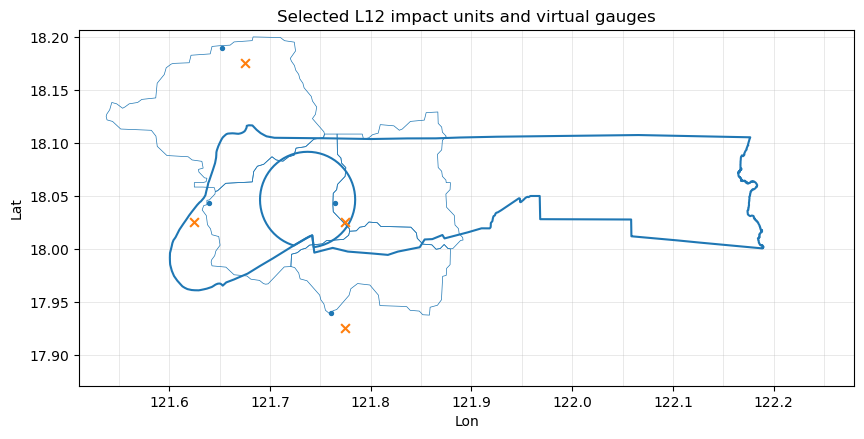

In [9]:
import geopandas as gpd
from shapely.geometry import Point

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Open one sample GRIB to get the GloFAS grid
inventory = discover_grib_year_files(glofas_grib_root)
sample_grib = inventory[0].grib_path
ds = open_grib_dataset(sample_grib, index_dir=index_dir)

# Add subtle GloFAS grid behind everything (bbox from selected_l12)
bbox = tuple(adm3_gdf.loc[adm3_gdf[adm3_id_field].isin(adm3_ids), "geometry"].total_bounds)
add_glofas_grid_overlay(ax, ds, bbox_lonlat=bbox, pad_deg=0.25)

try:
    ds.close()
except Exception:
    pass

# Base: selected L12
selected_l12.boundary.plot(ax=ax, linewidth=0.5, zorder=2)

# AOI (if any)
if USE_MUNI_AOI:
    aoi_gdf = gpd.GeoDataFrame({"geometry": aoi_geoms}, crs="EPSG:4326")
    aoi_gdf.boundary.plot(ax=ax, linewidth=1.5, zorder=3)
    adm3_gdf[adm3_gdf[adm3_id_field].isin(adm3_ids)].boundary.plot(ax=ax, linewidth=1.5, zorder=3)

# Pour points
pp = gpd.GeoDataFrame(
    points_df,
    geometry=[Point(xy) for xy in zip(points_df.pour_lon, points_df.pour_lat)],
    crs="EPSG:4326",
)
pp.plot(ax=ax, markersize=8, zorder=4)

# Virtual gauges (unique cells): these are the grid-cell centers you snapped to
vg_unique = points_df.drop_duplicates("virtual_gauge_id").copy()
vg = gpd.GeoDataFrame(
    vg_unique,
    geometry=[Point(xy) for xy in zip(vg_unique.cell_lon, vg_unique.cell_lat)],
    crs="EPSG:4326",
)
vg.plot(ax=ax, markersize=40, marker="x", zorder=5)

ax.set_title("Selected L12 impact units and virtual gauges")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
# Zoom to selected municipalities bounds (with a small margin)
m_bounds = adm3_gdf.loc[adm3_gdf[adm3_id_field].isin(adm3_ids), "geometry"].total_bounds
minx, miny, maxx, maxy = m_bounds
pad = 0.09  # degrees; try 0.02–0.10 depending on how tight you want it
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)
plt.show()

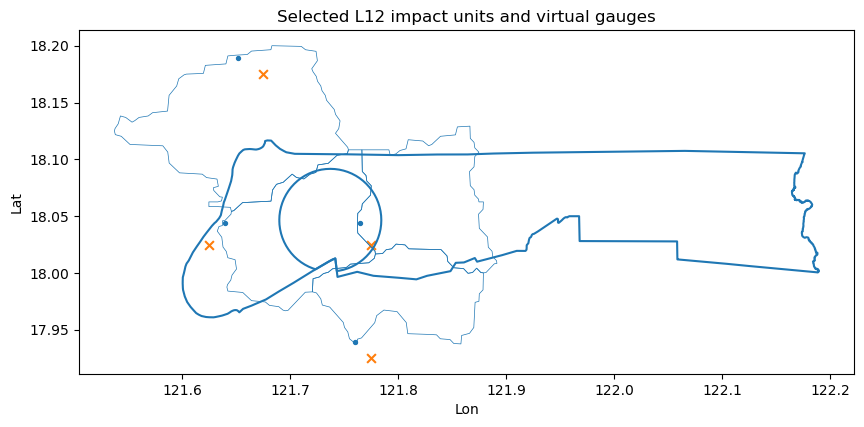

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Base: selected L12
selected_l12.boundary.plot(ax=ax, linewidth=0.5)

# AOI (if any)
if USE_MUNI_AOI:
    aoi_gdf = gpd.GeoDataFrame({"geometry": aoi_geoms}, crs="EPSG:4326")
    aoi_gdf.boundary.plot(ax=ax, linewidth=1.5)
    adm3_gdf[adm3_gdf[adm3_id_field].isin(adm3_ids)].boundary.plot(ax=ax, linewidth=1.5)

# Pour points
pp = gpd.GeoDataFrame(points_df, geometry=[Point(xy) for xy in zip(points_df.pour_lon, points_df.pour_lat)], crs="EPSG:4326")
pp.plot(ax=ax, markersize=8)

# Virtual gauges (unique cells)
vg_unique = points_df.drop_duplicates("virtual_gauge_id").copy()
vg = gpd.GeoDataFrame(vg_unique, geometry=[Point(xy) for xy in zip(vg_unique.cell_lon, vg_unique.cell_lat)], crs="EPSG:4326")
vg.plot(ax=ax, markersize=40, marker="x")

ax.set_title("Selected L12 impact units and virtual gauges")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
plt.show()
## Add rivers and Grids

## 7) Write mapping tables 

We write:
- municipality → AOI → selected L12 (if AOI mode)
- L12 → pour point
- L12 → virtual gauge (GloFAS cell) + collision sizes


In [9]:
out_root = processed_root / "calibration" / "evt_pot" / (basin_cfg.basin_id if basin_cfg else "MUNI_SELECTION") / run_tag
mapping_dir = out_root / "mapping"
aoi_dir = out_root / "aoi"
for d in [mapping_dir, aoi_dir]:
    d.mkdir(parents=True, exist_ok=True)

# A) muni → AOI → L12
if USE_MUNI_AOI:
    muni_aoi_df = pd.DataFrame(muni_aoi_records)
    muni_aoi_df.to_parquet(mapping_dir / "muni_aoi_l12.parquet", index=False)

    # Save AOI geometries
    import geopandas as gpd
    aoi_gdf = gpd.GeoDataFrame(muni_aoi_df[["adm3_id", "centroid_lon", "centroid_lat", "total_population", "valid_pixel_count"]].copy(),
                              geometry=aoi_geoms, crs="EPSG:4326")
    aoi_gdf.to_file(aoi_dir / "municipality_aoi.geojson", driver="GeoJSON")

# B) L12 → pour point
l12_pour = points_df[["l12_id", "pour_lon", "pour_lat"]].copy()
l12_pour.to_parquet(mapping_dir / "l12_pour_points.parquet", index=False)

# C) L12 → virtual gauge
l12_vg = points_df[["l12_id", "cell_lat", "cell_lon", "virtual_gauge_id", "collision_group_size"]].copy()
l12_vg.to_parquet(mapping_dir / "l12_to_virtual_gauge.parquet", index=False)

print("Wrote mapping tables to:", mapping_dir)


2026-01-20 17:30:27,654 - pyogrio._io - INFO - Created 1 records


Wrote mapping tables to: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib\mapping


In [10]:
from pathlib import Path

bad = []
small = []
ok = 0

for item in inventory:
    p = Path(item.grib_path)
    if not p.exists():
        bad.append((item.year, "MISSING", str(p)))
        continue

    size = p.stat().st_size
    head = p.open("rb").read(4)

    if head != b"GRIB":
        bad.append((item.year, f"NOT_GRIB magic={head!r}", str(p)))
        continue

    if size < 5 * 1024 * 1024:  # <5MB is suspicious for “yearly consolidated discharge”
        small.append((item.year, f"{size/1024**2:.2f} MB", str(p)))
        continue

    ok += 1

print("OK:", ok, "BAD:", len(bad), "SMALL:", len(small))
print("\nBAD examples:", bad[:5])
print("\nSMALL examples:", small[:5])


OK: 47 BAD: 0 SMALL: 0

BAD examples: []

SMALL examples: []


## 8) GRIB → daily discharge time series 
We extract only the **unique virtual gauges** needed for this run.

- Auto-detect available years
- Skip already-processed gauge parquet files (unless forced)


In [11]:
timeseries_dir = processed_root / "glofas" / "v4" / "area_35_63_4_131" / "timeseries" / "virtual_gauges"
timeseries_dir.mkdir(parents=True, exist_ok=True)

vg_points = points_df.drop_duplicates("virtual_gauge_id").rename(columns={"cell_lat": "lat", "cell_lon": "lon"})
vg_points = vg_points[["virtual_gauge_id", "lat", "lon"]].copy()

# Show year selection info
if SELECTED_YEARS is not None:
    print(f"⚠️  YEAR FILTERING ENABLED: Processing only {SELECTED_YEARS}")
    filtered_inventory = [i for i in inventory if i.year in SELECTED_YEARS]
    if not filtered_inventory:
        raise ValueError(f"No GRIBs found for selected years {SELECTED_YEARS}")
    print(f"    Processing {len(filtered_inventory)}/{len(inventory)} GRIB files")
else:
    print(f"Extracting discharge for {len(vg_points)} unique virtual gauges from {len(inventory)} GRIB files (all years)...")
    filtered_inventory = inventory

print("This may take several minutes. Each GRIB is processed with lazy (chunked) evaluation to prevent memory exhaustion.")
print("Note: Invalid dates (year=0 from ECCODES warnings) are automatically filtered out.\n")

# Extract or load cached time series
series_by_gauge = load_or_build_gauge_timeseries(
    grib_inventory=filtered_inventory,
    points=vg_points,
    processed_timeseries_dir=timeseries_dir,
    cfgrib_index_dir=index_dir,
    force=False,
    discharge_var=discharge_var,
    selected_years=SELECTED_YEARS,
)

print("\n✓ Successfully loaded/extracted gauges:", len(series_by_gauge))


⚠️  YEAR FILTERING ENABLED: Processing only [2010, 2011, 2012, 2013, 2014, 2015]
    Processing 6/47 GRIB files
This may take several minutes. Each GRIB is processed with lazy (chunked) evaluation to prevent memory exhaustion.
Note: Invalid dates (year=0 from ECCODES warnings) are automatically filtered out.


✓ Successfully loaded/extracted gauges: 4


## 9) QC summary (batch)


In [12]:
qc_rows = []
for gid, s in series_by_gauge.items():
    summ = qc_daily_series(s)
    row = {"virtual_gauge_id": gid}
    row.update(qc_summary_dict(summ))
    qc_rows.append(row)

qc_df = pd.DataFrame(qc_rows).sort_values(["missing_pct", "longest_missing_streak_days"], ascending=[True, False])
qc_df.to_parquet(out_root / "results" / "qc_summary.parquet", index=False) if (out_root / "results").mkdir(parents=True, exist_ok=True) is None else None
qc_df.head(20)


,virtual_gauge_id,start_date,end_date,n_days_expected,n_days_observed,missing_pct,longest_missing_streak_days,constant_segment_flag,constant_segment_max_days,spike_flag,spike_count
0,VG__lat_18.1750__lon_121.6750,2010-01-01,2015-12-31,2191,2191,0.0,0,False,0,True,55
1,VG__lat_18.0250__lon_121.6250,2010-01-01,2015-12-31,2191,2191,0.0,0,False,0,True,55
2,VG__lat_18.0250__lon_121.7750,2010-01-01,2015-12-31,2191,2191,0.0,0,False,0,True,86
3,VG__lat_17.9250__lon_121.7750,2010-01-01,2015-12-31,2191,2191,0.0,0,False,0,True,59


## 10) Interactive threshold selection (choose a gauge and find its POT threshold)

Use this block to pick a virtual gauge, review diagnostics, and lock in the POT threshold that will feed the save/log steps below. Nothing is written to disk in this section.

**Flow**
1. Run the widget to inspect diagnostics for a gauge (auto threshold is highlighted).
2. (Optional) Review candidate threshold stats to override manually.
3. Finalize the threshold to set `threshold_m3s`, `pot`, and `xi_sigma` for the save step.



In [13]:
import math
import numpy as np
import pandas as pd
from pyextremes import EVA

def _dynamic_min_events_total(
    coverage_years: float,
    target_lambda_rse: float = 0.20,   # 20% relative SE on lambda -> ~25 events
    min_floor: int = 10,
    max_events_per_year: float = 6.0,  # cap so short records don't force too-low thresholds
    want_gpd_params: bool = True,
):
    # For Poisson counts N ~ Pois(lambda*T), RSE(lambda_hat) ~ 1/sqrt(N)
    n_rate = math.ceil(1.0 / (target_lambda_rse ** 2))  # 0.20 -> 25
    n_gpd = 50 if want_gpd_params else 0               # classic heuristic for stable GPD params
    n_req = max(min_floor, n_rate, n_gpd)
    n_cap = max(min_floor, math.ceil(max_events_per_year * max(coverage_years, 0.0)))
    n_final = min(n_req, n_cap)
    status = "ok" if n_final == n_req else "capped_short_record"
    return int(n_final), status

def _get_fit_params(eva: EVA):
    """Robustly read fitted params from pyextremes model."""
    model = getattr(eva, "model", None)
    if model is None:
        return None
    # documented property
    fitp = getattr(model, "fit_parameters", None)
    if isinstance(fitp, dict) and len(fitp) > 0:
        return fitp
    # fallback (some versions expose params)
    fitp = getattr(model, "params", None)
    if isinstance(fitp, dict) and len(fitp) > 0:
        return fitp
    return None

def auto_select_threshold_pot(
    s: pd.Series,
    candidate_quantiles=(0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99),
    run_length_days: int = 5,
    min_events_total: int | str = "auto",          # int or "auto"
    target_lambda_range: tuple[float, float] | None = (1.0, 4.0),  # set None to disable
    stability_k: int = 3,                           # require stable region across k thresholds
    stability_tol_xi: float = 0.15,                 # abs range of xi within window
    stability_tol_sigma: float = 0.35,              # relative range of sigma within window
    dispersion_range: tuple[float, float] | None = (0.5, 2.0),
    dispersion_hard: bool = False,                  # False -> flag only; True -> gate
    require_gpd_params: bool = False,                # if True, thresholds without xi/sigma never pass
    verbose: bool = False,
):
    """
    Select the smallest threshold that yields declustered POT extremes consistent with GPD
    (operationalized via parameter-stability over a window) plus minimum event sufficiency.
    This follows the standard threshold-selection goal: pick the smallest threshold in a stable tail regime. :contentReference[oaicite:3]{index=3}
    """
    s = s.dropna().sort_index()
    if len(s) < 30 or not isinstance(s.index, pd.DatetimeIndex):
        raise ValueError("Input series must be a non-empty daily Series with a DatetimeIndex.")

    years = np.arange(s.index.min().year, s.index.max().year + 1)
    coverage_years = float(len(s) / 365.25)

    # Dynamic min events (optional)
    min_events_status = "fixed"
    if isinstance(min_events_total, str) and min_events_total.lower() == "auto":
        min_events_total, min_events_status = _dynamic_min_events_total(
            coverage_years=coverage_years,
            want_gpd_params=require_gpd_params,
        )

    thresholds = sorted({float(s.quantile(q)) for q in candidate_quantiles})
    r = f"{int(run_length_days)}D"

    eva = EVA(s)  # reuse for speed; get_extremes resets internal state
    rows = []

    for u in thresholds:
        eva.get_extremes(method="POT", threshold=float(u), r=r, extremes_type="high")
        ev = eva.extremes

        annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
        lam = float(annual.mean())
        disp = float((annual.var(ddof=1) / annual.mean())) if annual.mean() > 0 else np.nan

        xi = sigma = np.nan
        fit_ok = False
        try:
            eva.fit_model(distribution="genpareto")
            fit_params = _get_fit_params(eva)
            if isinstance(fit_params, dict):
                xi = float(fit_params.get("shape", fit_params.get("c", np.nan)))
                sigma = float(fit_params.get("scale", np.nan))
                fit_ok = (not np.isnan(xi)) and (not np.isnan(sigma)) and (sigma > 0)
        except Exception:
            fit_ok = False

        rows.append({
            "threshold": float(u),
            "n_events": int(len(ev)),
            "coverage_years": coverage_years,
            "lambda_per_year": lam,
            "dispersion_var_over_mean": disp,
            "xi": xi,
            "sigma": sigma,
            "gpd_fit_ok": bool(fit_ok),
        })

    df = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)

    # --- build pass flags ---
    df["meets_events"] = df["n_events"] >= int(min_events_total)

    if target_lambda_range is None:
        df["meets_lambda"] = True
    else:
        lo, hi = target_lambda_range
        df["meets_lambda"] = (df["lambda_per_year"] >= lo) & (df["lambda_per_year"] <= hi)

    if dispersion_range is None:
        df["meets_dispersion"] = True
    else:
        dlo, dhi = dispersion_range
        df["meets_dispersion"] = df["dispersion_var_over_mean"].between(dlo, dhi, inclusive="both")

    # Parameter stability over a rolling window of size k
    df["stable_k"] = False
    for i in range(len(df)):
        j0 = i - (stability_k - 1)
        if j0 < 0:
            continue
        win = df.loc[j0:i, ["xi", "sigma", "gpd_fit_ok"]]
        if require_gpd_params and (not win["gpd_fit_ok"].all()):
            continue
        if win["xi"].isna().any() or win["sigma"].isna().any():
            continue
        xi_range = float(win["xi"].max() - win["xi"].min())
        sigma_min = float(win["sigma"].min())
        sigma_max = float(win["sigma"].max())
        sigma_rel = (sigma_max / sigma_min - 1.0) if sigma_min > 0 else np.inf

        if (xi_range <= stability_tol_xi) and (sigma_rel <= stability_tol_sigma):
            df.at[i, "stable_k"] = True

    # Final pass logic
    if dispersion_hard:
        df["passes"] = df["meets_events"] & df["meets_lambda"] & df["meets_dispersion"] & df["stable_k"]
    else:
        df["passes"] = df["meets_events"] & df["meets_lambda"] & df["stable_k"]
        # still keep dispersion as QC flag
        df["dispersion_flag"] = ~df["meets_dispersion"]

    # Pick the smallest threshold in a stable region
    if df["passes"].any():
        pick = float(df.loc[df["passes"]].iloc[0]["threshold"])
        status = "ok"
    else:
        # fallback: pick smallest threshold that at least meets events (or highest threshold if nothing meets)
        if df["meets_events"].any():
            pick = float(df.loc[df["meets_events"]].iloc[0]["threshold"])
            status = "fallback_events_only_no_stable_region"
        else:
            pick = float(df.iloc[-1]["threshold"])
            status = "fallback_no_threshold_passed"

    if verbose:
        print(f"[auto_select_threshold_pot] min_events_total={min_events_total} ({min_events_status}), "
              f"target_lambda_range={target_lambda_range}, stability_k={stability_k}, status={status}, pick={pick:.2f}")

    # store key config in attrs for traceability
    df.attrs = {
        "run_length_days": int(run_length_days),
        "min_events_total": int(min_events_total),
        "min_events_status": min_events_status,
        "target_lambda_range": target_lambda_range,
        "stability_k": int(stability_k),
        "stability_tol_xi": float(stability_tol_xi),
        "stability_tol_sigma": float(stability_tol_sigma),
        "dispersion_range": dispersion_range,
        "dispersion_hard": bool(dispersion_hard),
        "require_gpd_params": bool(require_gpd_params),
    }

    return pick, status, df


In [14]:
import numpy as np
import pandas as pd
from pathlib import Path

from pyextremes import EVA

# Ensure helper is available even if previous cell was skipped
try:
    auto_select_threshold_pot
except NameError:
    from pyextremes import EVA as _EVA
    def auto_select_threshold_pot(
        s: pd.Series,
        candidate_quantiles=(0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99),
        run_length_days=5,
        min_events_total=50,
        stability_tol_xi=0.15,
        stability_tol_sigma=0.35,
        dispersion_range=(0.5, 2.0),
        verbose=False,
    ):
        if verbose:
            print(f"[auto_select_threshold_pot] Received parameters:")
            print(f"  candidate_quantiles: {candidate_quantiles}")
            print(f"  run_length_days: {run_length_days}")
            print(f"  min_events_total: {min_events_total}")
            print(f"  stability_tol_xi: {stability_tol_xi}")
            print(f"  stability_tol_sigma: {stability_tol_sigma}")
            print(f"  dispersion_range: {dispersion_range}")
        s = s.dropna().sort_index()
        years = np.arange(s.index.min().year, s.index.max().year + 1)
        thresholds = sorted({float(s.quantile(q)) for q in candidate_quantiles})
        rows = []
        prev_xi = prev_sigma = None
        for u in thresholds:
            eva = _EVA(s)
            eva.get_extremes(method="POT", threshold=float(u), r=f"{int(run_length_days)}D", extremes_type="high")
            ev = eva.extremes
            annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
            lam = annual.mean()
            disp = (annual.var(ddof=1) / annual.mean()) if annual.mean() > 0 else np.nan
            xi = sigma = np.nan
            try:
                eva.fit_model(distribution="genpareto")
                params = getattr(getattr(eva, "model", None), "params", None)
                if isinstance(params, dict):
                    xi = float(params.get("shape", params.get("c", np.nan)))
                    sigma = float(params.get("scale", np.nan))
            except Exception:
                pass
            stable = True
            if prev_xi is not None and not np.isnan(xi) and not np.isnan(prev_xi):
                stable &= (abs(xi - prev_xi) <= stability_tol_xi)
            if prev_sigma is not None and not np.isnan(sigma) and not np.isnan(prev_sigma) and prev_sigma > 0:
                stable &= (abs((sigma / prev_sigma) - 1.0) <= stability_tol_sigma)
            passes = ((len(ev) >= min_events_total) and (dispersion_range[0] <= disp <= dispersion_range[1]) and stable)
            rows.append({
                "threshold": u,
                "n_events": int(len(ev)),
                "lambda_per_year": float(lam),
                "dispersion_var_over_mean": float(disp) if disp == disp else np.nan,
                "xi": float(xi) if xi == xi else np.nan,
                "sigma": float(sigma) if sigma == sigma else np.nan,
                "stable_vs_prev": bool(stable),
                "passes": bool(passes),
            })
            prev_xi, prev_sigma = xi, sigma
        df = pd.DataFrame(rows).sort_values("threshold")
        if df["passes"].any():
            pick = float(df.loc[df["passes"]].iloc[0]["threshold"])
            status = "ok"
        else:
            pick = float(df.iloc[-1]["threshold"])
            status = "fallback_no_threshold_passed"
        return pick, status, df

# ============================================================================
# BATCH PROCESSING: Generate diagnostic stats + auto-select thresholds
# for ALL gauges. This runs once to populate the results folder.
# ============================================================================

# --- Calibration config (centralized for consistency across all Section 10 cells) ---
RUN_LENGTH_DAYS = int(run_length_days)  # uses notebook variable from Section 1
CANDIDATE_QUANTILES = candidate_quantiles if "candidate_quantiles" in globals() else (0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99)
MIN_EVENTS_TOTAL = "auto"  # minimum events required for a threshold to pass
STABILITY_TOL_XI = 0.15
STABILITY_TOL_SIGMA = 0.35
DISPERSION_RANGE = (0.5, 2.0)

MIN_EVENTS_TOTAL = "auto"              # <- dynamic per gauge
TARGET_LAMBDA_RANGE = (1.0, 4.0)       # <- optional; set None to disable
STABILITY_K = 3
DISPERSION_HARD = False               # <- keep dispersion as flag for now

# Output location
diag_root = (out_root / "results" / "diagnostics_by_gauge") if "out_root" in globals() else Path("./results/diagnostics_by_gauge")
diag_root.mkdir(parents=True, exist_ok=True)

print(f"=" * 70)
print(f"BATCH DIAGNOSTICS CONFIG:")
print(f"  RUN_LENGTH_DAYS:      {RUN_LENGTH_DAYS}")
print(f"  CANDIDATE_QUANTILES:  {CANDIDATE_QUANTILES}")
print(f"  MIN_EVENTS_TOTAL:     {MIN_EVENTS_TOTAL}")
print(f"  STABILITY_TOL_XI:     {STABILITY_TOL_XI}")
print(f"  STABILITY_TOL_SIGMA:  {STABILITY_TOL_SIGMA}")
print(f"  DISPERSION_RANGE:     {DISPERSION_RANGE}")
print(f"=" * 70)

summary_rows = []

gauge_ids = sorted(series_by_gauge.keys())
print(f"\nGenerating diagnostics for {len(gauge_ids)} gauge(s)…")
print(f"Output folder: {diag_root.resolve()}\n")

for i, gid in enumerate(gauge_ids, start=1):
    s = series_by_gauge[gid].dropna().sort_index()
    if len(s) == 0:
        continue

    coverage_years = float(len(s) / 365.25)
    q95 = float(s.quantile(0.95))

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        target_lambda_range=TARGET_LAMBDA_RANGE,
        stability_k=STABILITY_K,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        dispersion_hard=DISPERSION_HARD,
        require_gpd_params=True,
        verbose=False,
)

    gdir = diag_root / gid
    gdir.mkdir(parents=True, exist_ok=True)

    # Save diagnostics table per gauge
    diag_df.to_parquet(gdir / "threshold_diagnostics.parquet", index=False)

    summary_rows.append({
        "virtual_gauge_id": gid,
        "coverage_years": coverage_years,
        "q95_m3s": q95,
        "u_auto_m3s": float(pick_u),
        "auto_status": pick_status,
        "n_events_at_u_auto": int(diag_df.loc[diag_df["threshold"] == pick_u, "n_events"].iloc[0]) if (diag_df["threshold"] == pick_u).any() else np.nan,
        "auto_status": pick_status,
        "dispersion_flag_at_pick": bool(diag_df.loc[diag_df["threshold"] == pick_u, "dispersion_flag"].iloc[0]) if "dispersion_flag" in diag_df.columns else False,
    })

    if i % 10 == 0 or i == len(gauge_ids):
        print(f"  [{i}/{len(gauge_ids)}] done")

# Save aggregate summary
summary_df = pd.DataFrame(summary_rows).sort_values(["auto_status", "coverage_years"], ascending=[True, False])
summary_df.to_parquet(diag_root / "_summary.parquet", index=False)
print(f"\n✓ Batch diagnostics complete. Summary saved to: {diag_root / '_summary.parquet'}")
display(summary_df.head(20))


2026-01-20 17:30:28,351 - pyextremes.eva - INFO - successfully initialized EVA object
2026-01-20 17:30:28,355 - pyextremes.eva - INFO - successfully extracted extreme values for method='POT' and extremes_type='high'
2026-01-20 17:30:28,356 - pyextremes.eva - INFO - successfully collected extreme value properties
2026-01-20 17:30:28,356 - pyextremes.eva - INFO - successfully created extremes transformer
2026-01-20 17:30:28,357 - pyextremes.eva - INFO - removing any previously declared models
2026-01-20 17:30:28,378 - pyextremes.eva - INFO - successfully extracted extreme values for method='POT' and extremes_type='high'
2026-01-20 17:30:28,378 - pyextremes.eva - INFO - successfully collected extreme value properties
2026-01-20 17:30:28,379 - pyextremes.eva - INFO - successfully created extremes transformer
2026-01-20 17:30:28,379 - pyextremes.eva - INFO - removing any previously declared models
2026-01-20 17:30:28,400 - pyextremes.eva - INFO - successfully extracted extreme values for me

BATCH DIAGNOSTICS CONFIG:
  RUN_LENGTH_DAYS:      5
  CANDIDATE_QUANTILES:  [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
  MIN_EVENTS_TOTAL:     auto
  STABILITY_TOL_XI:     0.15
  STABILITY_TOL_SIGMA:  0.35
  DISPERSION_RANGE:     (0.5, 2.0)

Generating diagnostics for 4 gauge(s)…
Output folder: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib\results\diagnostics_by_gauge



2026-01-20 17:30:28,550 - pyextremes.eva - INFO - successfully extracted extreme values for method='POT' and extremes_type='high'
2026-01-20 17:30:28,551 - pyextremes.eva - INFO - successfully collected extreme value properties
2026-01-20 17:30:28,552 - pyextremes.eva - INFO - successfully created extremes transformer
2026-01-20 17:30:28,552 - pyextremes.eva - INFO - removing any previously declared models
2026-01-20 17:30:28,584 - pyextremes.eva - INFO - successfully initialized EVA object
2026-01-20 17:30:28,588 - pyextremes.eva - INFO - successfully extracted extreme values for method='POT' and extremes_type='high'
2026-01-20 17:30:28,589 - pyextremes.eva - INFO - successfully collected extreme value properties
2026-01-20 17:30:28,589 - pyextremes.eva - INFO - successfully created extremes transformer
2026-01-20 17:30:28,590 - pyextremes.eva - INFO - removing any previously declared models
2026-01-20 17:30:28,614 - pyextremes.eva - INFO - successfully extracted extreme values for me

  [4/4] done

✓ Batch diagnostics complete. Summary saved to: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib\results\diagnostics_by_gauge\_summary.parquet


,virtual_gauge_id,coverage_years,q95_m3s,u_auto_m3s,auto_status,n_events_at_u_auto,dispersion_flag_at_pick
0,VG__lat_17.9250__lon_121.7750,5.998631,208.300781,145.281250,fallback_events_only_no_stable_region,41,False
1,VG__lat_18.0250__lon_121.6250,5.998631,4503.773438,3169.414062,fallback_events_only_no_stable_region,37,False
2,VG__lat_18.0250__lon_121.7750,5.998631,55.281250,38.203125,fallback_events_only_no_stable_region,39,False
3,VG__lat_18.1750__lon_121.6750,5.998631,4601.589844,3265.812500,fallback_events_only_no_stable_region,37,False


In [15]:
# ============================================================================
# STEP 1: Select a gauge and view diagnostics + auto-recommended threshold
# ============================================================================
import logging
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from pyextremes import EVA, plot_mean_residual_life, plot_parameter_stability
from pyextremes.plotting.extremes import plot_extremes

logging.getLogger("pyextremes").setLevel(logging.WARNING)

print(f"Using config from batch processing cell:")
print(f"  RUN_LENGTH_DAYS:      {RUN_LENGTH_DAYS}")
print(f"  CANDIDATE_QUANTILES:  {CANDIDATE_QUANTILES}")
print(f"  MIN_EVENTS_TOTAL:     {MIN_EVENTS_TOTAL}")
print(f"  STABILITY_TOL_XI:     {STABILITY_TOL_XI}")
print(f"  STABILITY_TOL_SIGMA:  {STABILITY_TOL_SIGMA}")
print(f"  DISPERSION_RANGE:     {DISPERSION_RANGE}\n")


def _plot_mrl(s, q95, pick_u):
    plot_mean_residual_life(s)
    ax = plt.gca()
    ax.axvline(q95, linestyle="--", linewidth=2, color="red", label=f"q95={q95:.2f}")
    ax.axvline(pick_u, linestyle="-.", linewidth=2, color="green", label=f"u*={pick_u:.2f}")
    ax.set_title("Mean Residual Life")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def _plot_parameter_stability(s, q95, pick_u):
    thr_grid = np.linspace(float(s.quantile(0.90)), float(s.quantile(0.995)), 40)
    plot_parameter_stability(s, thresholds=thr_grid, r=f"{RUN_LENGTH_DAYS}D")
    ax = plt.gca()
    ax.axvline(q95, linestyle="--", linewidth=2, color="red", label=f"q95={q95:.2f}")
    ax.axvline(pick_u, linestyle="-.", linewidth=2, color="green", label=f"u*={pick_u:.2f}")
    ax.set_title(f"Parameter stability (r={RUN_LENGTH_DAYS}D)")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def _plot_pot_extremes(s, pick_u):
    eva = EVA(s)
    eva.get_extremes(method="POT", threshold=float(pick_u), r=f"{RUN_LENGTH_DAYS}D", extremes_type="high")
    fig, ax = plt.subplots(figsize=(12, 5))
    plot_extremes(
        ts=s,
        extremes=eva.extremes,
        extremes_method="POT",
        extremes_type="high",
        threshold=float(pick_u),
        r=f"{RUN_LENGTH_DAYS}D",
        ax=ax,
    )
    ax.set_title(f"POT extremes (u*={pick_u:.2f}, r={RUN_LENGTH_DAYS}D)")
    plt.tight_layout()
    plt.show()


def show_gauge_diag(gid):
    """Display diagnostics for a selected gauge and store selection globally."""
    global selected_gauge_id, diag_df
    selected_gauge_id = gid
    s = series_by_gauge[gid].dropna().sort_index()
    q95 = float(s.quantile(0.95))

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        verbose=True,  # Show diagnostic info
    )

    _plot_mrl(s, q95, pick_u)
    _plot_parameter_stability(s, q95, pick_u)
    _plot_pot_extremes(s, pick_u)

    print(f"\nAUTO threshold selection: {pick_status}")
    print(f"Picked threshold: {pick_u:.2f} m³/s")
    display(diag_df)


if HAS_WIDGETS:
    dropdown = widgets.Dropdown(options=sorted(series_by_gauge.keys()), description="Gauge:")
    ui = widgets.interactive(show_gauge_diag, gid=dropdown)
    display(ui)
else:
    fallback_gid = sorted(series_by_gauge.keys())[0]
    print(f"Widgets not available. Using first gauge: {fallback_gid}")
    show_gauge_diag(fallback_gid)


Using config from batch processing cell:
  RUN_LENGTH_DAYS:      5
  CANDIDATE_QUANTILES:  [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
  MIN_EVENTS_TOTAL:     auto
  STABILITY_TOL_XI:     0.15
  STABILITY_TOL_SIGMA:  0.35
  DISPERSION_RANGE:     (0.5, 2.0)



interactive(children=(Dropdown(description='Gauge:', options=('VG__lat_17.9250__lon_121.7750', 'VG__lat_18.025…

In [16]:
# STEP 2 (Optional): Review all candidate thresholds for manual override
# This table shows statistics for different threshold choices
# Usually, you'll accept the auto-selected threshold from the widget above

import pandas as pd
import numpy as np
from pyextremes import EVA

s = series_by_gauge[selected_gauge_id].dropna().sort_index()

print(f"Computing threshold statistics for: {selected_gauge_id}")
print(f"Using RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, CANDIDATE_QUANTILES={CANDIDATE_QUANTILES}\n")


def pot_stats(s, u, run_length_days):
    """Calculate POT statistics for a given threshold."""
    eva = EVA(s)
    eva.get_extremes(method="POT", threshold=float(u), r=f"{int(run_length_days)}D", extremes_type="high")
    ev = eva.extremes
    years = np.arange(s.index.min().year, s.index.max().year + 1)
    annual = ev.groupby(ev.index.year).size().reindex(years, fill_value=0)
    lam = annual.mean()
    disp = (annual.var(ddof=1) / annual.mean()) if annual.mean() > 0 else np.nan
    return dict(
        threshold=float(u),
        n_events=int(len(ev)),
        lambda_per_year=float(lam),
        dispersion=float(disp) if disp == disp else np.nan,
    )


cand = sorted({float(s.quantile(q)) for q in CANDIDATE_QUANTILES})
rows = [pot_stats(s, u, RUN_LENGTH_DAYS) for u in cand]
threshold_table = pd.DataFrame(rows).sort_values("threshold")
print("Candidate thresholds and their event counts:")
display(threshold_table)


Computing threshold statistics for: VG__lat_17.9250__lon_121.7750
Using RUN_LENGTH_DAYS=5, CANDIDATE_QUANTILES=[0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

Candidate thresholds and their event counts:


,threshold,n_events,lambda_per_year,dispersion
0,145.281250,41,6.833333,0.726829
1,155.589066,38,6.333333,0.421053
2,165.045319,33,5.500000,0.636364
3,175.643753,32,5.333333,0.800000
4,192.806244,30,5.000000,0.560000
5,208.300781,26,4.333333,0.984615
6,245.059372,23,3.833333,1.400000
7,280.045319,22,3.666667,1.709091
8,327.248444,15,2.500000,1.080000
9,422.231262,10,1.666667,1.360000


In [17]:
# STEP 3: Finalize threshold (use auto-selected or override manually)
# Set `threshold_override` to a float to bypass the auto-picked value.

threshold_override = None  # e.g., 250.0 to manually override

print(f"Finalizing threshold for: {selected_gauge_id}")
print(f"Config: RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, MIN_EVENTS_TOTAL={MIN_EVENTS_TOTAL}")
if threshold_override is not None:
    print(f"⚠️  MANUAL OVERRIDE: Using threshold_m3s={threshold_override}")

pick_u, pick_status, diag_df = auto_select_threshold_pot(
    s,
    candidate_quantiles=CANDIDATE_QUANTILES,
    run_length_days=RUN_LENGTH_DAYS,
    min_events_total=MIN_EVENTS_TOTAL,
    stability_tol_xi=STABILITY_TOL_XI,
    stability_tol_sigma=STABILITY_TOL_SIGMA,
    dispersion_range=DISPERSION_RANGE,
    verbose=False,
)

threshold_m3s = float(threshold_override) if threshold_override is not None else pick_u
pot = pot_extract(s, threshold_m3s=threshold_m3s, run_length_days=RUN_LENGTH_DAYS)
xi_sigma = fit_gpd_to_pot(s, threshold_m3s=threshold_m3s, run_length_days=RUN_LENGTH_DAYS)

print(f"\n{'='*60}")
print(f"FINAL RESULTS FOR: {selected_gauge_id}")
print(f"{'='*60}")
print(f"Selected threshold: {threshold_m3s:.2f} m³/s ({pick_status})")
if threshold_override is not None:
    print(f"  (MANUAL override, auto picked: {pick_u:.2f})")
print(f"Flood events found: {len(pot.events)}")
print(f"Lambda (avg events/year): {pot.lambda_events_per_year:.3f}")
print(f"Data coverage: {pot.coverage_years:.1f} years")
if xi_sigma:
    print(f"GPD shape (xi): {xi_sigma[0]:.4f}")
    print(f"GPD scale (sigma): {xi_sigma[1]:.4f}")
print(f"{'='*60}")


Finalizing threshold for: VG__lat_17.9250__lon_121.7750
Config: RUN_LENGTH_DAYS=5, MIN_EVENTS_TOTAL=auto

FINAL RESULTS FOR: VG__lat_17.9250__lon_121.7750
Selected threshold: 145.28 m³/s (fallback_events_only_no_stable_region)
Flood events found: 41
Lambda (avg events/year): 6.835
Data coverage: 6.0 years
GPD shape (xi): -0.0014
GPD scale (sigma): 160.4065


### How the automatic threshold selection works (non-technical explanation)

**The goal:** Find the best river discharge level to identify "flood" events

**The method:**
1. Tests different possible thresholds (from 90th to 99.9th percentile of flow)
2. For each threshold, calculates how many flood events it finds
3. Checks if the statistical model is **stable** (parameters don't jump around wildly)
4. Picks the **lowest threshold** that still has a stable model

**Why this matters:**
- Too LOW a threshold = every small rise is called a "flood" (too many false alarms)
- Too HIGH a threshold = miss real flood events (not enough data to fit model)
- We want the sweet spot: reliable statistics with meaningful flood events

**Technical detail:** Uses GPD (Generalized Pareto Distribution) and checks for stability in shape (ξ) and scale (σ) parameters across adjacent thresholds.

## 11) Save & Validate POT Calibration Outputs

**What this section does:** Extracts "extreme flood events" (called POT events) from the river discharge data.

**In plain language:**
- Uses the best threshold from Section 10 to find significant river events
- Saves each event with its date and discharge level
- Fits a mathematical model to describe how rare extreme events are
- Creates 4 output files: one for each monitoring station

**Outputs you'll see:**
- Event files with flood peaks
- A table with threshold values and statistical parameters
- Quality checks to make sure everything looks reasonable


In [18]:
events_dir = out_root / "events"
results_dir = out_root / "results"
logs_dir = out_root / "logs"
for d in [events_dir, results_dir, logs_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Optional manual overrides per gauge (populate manually as needed)
# Example: MANUAL_THRESHOLD_OVERRIDES = {"VG__lat_12.3456__lon_98.7654": 250.0}
MANUAL_THRESHOLD_OVERRIDES = {}

print("Saving POT events and results for ALL gauges…")
print(f"Config: RUN_LENGTH_DAYS={RUN_LENGTH_DAYS}, MIN_EVENTS_TOTAL={MIN_EVENTS_TOTAL}, CANDIDATE_QUANTILES={CANDIDATE_QUANTILES}\n")

result_rows = []

for idx, (gid, s_raw) in enumerate(series_by_gauge.items(), start=1):
    s = s_raw.dropna().sort_index()
    if len(s) == 0:
        print(f"[{idx}/{len(series_by_gauge)}] {gid}: skipped (no data)")
        continue

    pick_u, pick_status, diag_df = auto_select_threshold_pot(
        s,
        candidate_quantiles=CANDIDATE_QUANTILES,
        run_length_days=RUN_LENGTH_DAYS,
        min_events_total=MIN_EVENTS_TOTAL,
        stability_tol_xi=STABILITY_TOL_XI,
        stability_tol_sigma=STABILITY_TOL_SIGMA,
        dispersion_range=DISPERSION_RANGE,
        verbose=False,
    )

    threshold_use = MANUAL_THRESHOLD_OVERRIDES.get(gid, pick_u)
    threshold_source = "manual_override" if gid in MANUAL_THRESHOLD_OVERRIDES else pick_status

    pot_res = pot_extract(s, threshold_m3s=threshold_use, run_length_days=RUN_LENGTH_DAYS)
    xi_sigma_local = fit_gpd_to_pot(s, threshold_m3s=threshold_use, run_length_days=RUN_LENGTH_DAYS)

    # Save events for this gauge
    pot_events_path = events_dir / f"{gid}__pot_events.parquet"
    pot_res.events.to_parquet(pot_events_path, index=False)

    result_rows.append({
        "virtual_gauge_id": gid,
        "threshold_m3s": pot_res.threshold_m3s,
        "threshold_source": threshold_source,
        "run_length_days": pot_res.run_length_days,
        "lambda_events_per_year": pot_res.lambda_events_per_year,
        "coverage_years": pot_res.coverage_years,
        "gpd_xi": float(xi_sigma_local[0]) if xi_sigma_local else None,
        "gpd_sigma": float(xi_sigma_local[1]) if xi_sigma_local else None,
    })

    if idx % 10 == 0 or idx == len(series_by_gauge):
        print(f"  [{idx}/{len(series_by_gauge)}] saved events + result row")

# Append/update aggregated results table
results_path = results_dir / "evt_pot_calibration.parquet"
if results_path.exists():
    existing = pd.read_parquet(results_path)
    # Drop rows for gauges we are overwriting in this run
    keep = existing[~existing["virtual_gauge_id"].isin([r["virtual_gauge_id"] for r in result_rows])]
    result_df = pd.concat([keep, pd.DataFrame(result_rows)], ignore_index=True)
else:
    result_df = pd.DataFrame(result_rows)

result_df.to_parquet(results_path, index=False)
print("\n✓ Wrote aggregated results:", results_path)
print("✓ Events directory:", events_dir)


Saving POT events and results for ALL gauges…
Config: RUN_LENGTH_DAYS=5, MIN_EVENTS_TOTAL=auto, CANDIDATE_QUANTILES=[0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]

  [4/4] saved events + result row

✓ Wrote aggregated results: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib\results\evt_pot_calibration.parquet
✓ Events directory: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib\events


## 11b) QA — Verify POT calibration outputs

Quick validation of saved calibration results:
- Aggregated threshold & GPD parameter table
- Per-gauge event files with extracted POT events
- Summary statistics for all gauges


In [19]:
"""
Section 11b QA: Verify all POT calibration outputs were saved correctly.
Displays:
  - Aggregated results (one row per gauge)
  - List of event files
  - Sample event records from first gauge
"""

from pathlib import Path
import pandas as pd

print("=" * 90)
print("SECTION 11B: QUALITY ASSURANCE — POT Calibration Outputs")
print("=" * 90)

# Load aggregated results
results_path = results_dir / "evt_pot_calibration.parquet"
print(f"\n1) Aggregated Results Table")
print(f"   Path: {results_path}")

if results_path.exists():
    calib_results = pd.read_parquet(results_path)
    print(f"   ✓ Loaded {len(calib_results)} gauge calibrations")
    print(f"   Columns: {list(calib_results.columns)}")
    print(f"\n   Summary Statistics:")
    print(f"   - Threshold range: {calib_results['threshold_m3s'].min():.1f}–{calib_results['threshold_m3s'].max():.1f} m³/s")
    print(f"   - λ (events/year) range: {calib_results['lambda_events_per_year'].min():.2f}–{calib_results['lambda_events_per_year'].max():.2f}")
    print(f"   - Run length: {calib_results['run_length_days'].unique()}")
    print(f"\n   Threshold sources:")
    print(calib_results['threshold_source'].value_counts().to_string())
    print(f"\n   Table preview:")
    display(calib_results)
else:
    print(f"   ✗ Results file not found!")

# List event files
print(f"\n2) Per-Gauge Event Files")
if events_dir.exists():
    event_files = sorted(events_dir.glob("*__pot_events.parquet"))
    print(f"   ✓ Found {len(event_files)} POT event files")
    for i, p in enumerate(event_files, start=1):
        ev_sample = pd.read_parquet(p)
        print(f"   [{i}] {p.name}: {len(ev_sample)} events")
    
    # Sample from first gauge
    if event_files:
        print(f"\n3) Sample: First gauge POT events")
        event_path = event_files[0]
        df_events = pd.read_parquet(event_path)
        gauge_id = event_path.stem.replace("__pot_events", "")
        print(f"   Gauge: {gauge_id}")
        print(f"   Total events: {len(df_events)}")
        print(f"   Date range: {df_events['date'].min().date()} to {df_events['date'].max().date()}")
        print(f"   Discharge range: {df_events['discharge_m3s'].min():.1f}–{df_events['discharge_m3s'].max():.1f} m³/s")
        print(f"\n   Sample rows:")
        display(df_events.head(10))
else:
    print(f"   ✗ Events directory not found!")

print("\n" + "=" * 90)
print("✓ Section 11 QA complete")
print("=" * 90)


SECTION 11B: QUALITY ASSURANCE — POT Calibration Outputs

1) Aggregated Results Table
   Path: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib\results\evt_pot_calibration.parquet
   ✓ Loaded 4 gauge calibrations
   Columns: ['virtual_gauge_id', 'threshold_m3s', 'threshold_source', 'run_length_days', 'lambda_events_per_year', 'coverage_years', 'gpd_xi', 'gpd_sigma']

   Summary Statistics:
   - Threshold range: 38.2–3265.8 m³/s
   - λ (events/year) range: 6.17–6.83
   - Run length: [5]

   Threshold sources:
threshold_source
fallback_events_only_no_stable_region    4

   Table preview:


,virtual_gauge_id,threshold_m3s,threshold_source,run_length_days,lambda_events_per_year,coverage_years,gpd_xi,gpd_sigma
0,VG__lat_18.1750__lon_121.6750,3265.812500,fallback_events_only_no_stable_region,5,6.168074,5.998631,-0.123218,3300.812135
1,VG__lat_18.0250__lon_121.6250,3169.414062,fallback_events_only_no_stable_region,5,6.168074,5.998631,-0.111382,3176.716875
2,VG__lat_18.0250__lon_121.7750,38.203125,fallback_events_only_no_stable_region,5,6.501483,5.998631,0.034057,46.189439
3,VG__lat_17.9250__lon_121.7750,145.281250,fallback_events_only_no_stable_region,5,6.834893,5.998631,-0.001395,160.406496



2) Per-Gauge Event Files
   ✓ Found 4 POT event files
   [1] VG__lat_17.9250__lon_121.7750__pot_events.parquet: 41 events
   [2] VG__lat_18.0250__lon_121.6250__pot_events.parquet: 37 events
   [3] VG__lat_18.0250__lon_121.7750__pot_events.parquet: 39 events
   [4] VG__lat_18.1750__lon_121.6750__pot_events.parquet: 37 events

3) Sample: First gauge POT events
   Gauge: VG__lat_17.9250__lon_121.7750
   Total events: 41
   Date range: 2010-06-27 to 2015-12-17
   Discharge range: 145.6–796.8 m³/s

   Sample rows:


,date,discharge_m3s
0,2010-06-27,147.468750
1,2010-09-02,208.320312
2,2010-10-19,387.210938
3,2010-11-11,547.140625
4,2011-01-20,321.296875
5,2011-03-07,161.125000
6,2011-05-28,145.562500
7,2011-06-20,208.281250
8,2011-07-07,156.171875
9,2011-07-28,159.203125



✓ Section 11 QA complete


## 12) Synthetic Event Catalog Generation

Generate synthetic flood events for return-period analysis using the calibrated POT parameters:
- **Input:** Per-gauge thresholds, λ (Poisson rate), GPD shape (ξ) and scale (σ)
- **Method:** Poisson draws for annual event counts + GPD sampling for peak magnitudes
- **Output:** Synthetic event catalogs with dates, magnitudes, and theoretical return periods
- **Visualization:** Presentation-ready figures for stakeholder communication


In [33]:
# --- SECTION 12A: Configuration for synthetic event generation ---
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import warnings
from datetime import datetime, timezone

# USER-EDITABLE SETTINGS (Return-period driven)
MAX_RETURN_PERIOD_YEARS = 100          # Max return period to simulate
YEARS_PER_RETURN_PERIOD = 20           # Monte Carlo years per max RP (low=noisy but fast, high=stable but slow)
SIM_YEARS = int(MAX_RETURN_PERIOD_YEARS * YEARS_PER_RETURN_PERIOD)  # Total simulation years (400)

# Return periods for diagnostics + stakeholder reports
RETURN_PERIODS_REPORT = [2, 5, 10, 20, 50, 100]

# Synthetic calendar: ensure BASE_YEAR + SIM_YEARS < 2263 (pandas datetime64 limit)
BASE_YEAR = 1                     # Anchor year for synthetic dates
MIN_SEP_DAYS_WITHIN_YEAR = int(run_length_days) if "run_length_days" in globals() else 5  # Minimum separation (days)

# Reproducibility & output controls
GLOBAL_SEED = 42
WRITE_COMBINED_ALL_GAUGES = True      # Write combined catalog (may be large)
SAVE_OPTIONAL_CSV = False             # Also save CSV (slow for large catalogs)

# Warnings thresholds
WARN_IF_SIM_YEARS_LT_MULTIPLE_OF_MAX_RP = 50
WARN_IF_EXPECTED_EVENTS_LT = 2000
WARN_IF_REAL_POT_EVENTS_LT = 50

# Output folders
run_dir = results_dir.parent
synthetic_root = run_dir / "synthetic_catalog"
events_out_dir = synthetic_root / "events"
rl_out_dir = synthetic_root / "return_levels"
meta_out_dir = synthetic_root / "metadata"
fig_dir = synthetic_root / "figures"

for d in [events_out_dir, rl_out_dir, meta_out_dir, fig_dir]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 90)
print("SECTION 12A: Synthetic Event Catalog Configuration")
print("=" * 90)
print(f"MAX_RETURN_PERIOD_YEARS:   {MAX_RETURN_PERIOD_YEARS}")
print(f"YEARS_PER_RETURN_PERIOD:   {YEARS_PER_RETURN_PERIOD}")
print(f"SIM_YEARS:                 {SIM_YEARS}")
print(f"BASE_YEAR:                 {BASE_YEAR} (range: {BASE_YEAR}–{BASE_YEAR + SIM_YEARS})")
print(f"Synthetic catalog root:    {synthetic_root}")
print("=" * 90)

if BASE_YEAR + SIM_YEARS > 2262:
    raise ValueError(f"Year range {BASE_YEAR}–{BASE_YEAR + SIM_YEARS} exceeds datetime64 limit")

if YEARS_PER_RETURN_PERIOD < WARN_IF_SIM_YEARS_LT_MULTIPLE_OF_MAX_RP:
    warnings.warn(f"YEARS_PER_RETURN_PERIOD={YEARS_PER_RETURN_PERIOD} is low; tail estimates will be noisy")


SECTION 12A: Synthetic Event Catalog Configuration
MAX_RETURN_PERIOD_YEARS:   100
YEARS_PER_RETURN_PERIOD:   20
SIM_YEARS:                 2000
BASE_YEAR:                 1 (range: 1–2001)
Synthetic catalog root:    C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib\synthetic_catalog


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_26376\4066506192.py:57: UserWarning: YEARS_PER_RETURN_PERIOD=20 is low; tail estimates will be noisy
  warnings.warn(f"YEARS_PER_RETURN_PERIOD={YEARS_PER_RETURN_PERIOD} is low; tail estimates will be noisy")


In [34]:
# Section 12B — synthetic event generation (self-contained)
# Generates per-gauge synthetic catalogs + return levels using calibrated POT parameters.

import numpy as np
import pandas as pd
from datetime import timedelta

baseline_seed = GLOBAL_SEED
rng = np.random.default_rng(baseline_seed)

# Pull calibration results from disk if not already loaded
if "calib_results" not in globals():
    calib_results = pd.read_parquet(results_dir / "evt_pot_calibration.parquet")

# Helper: sample GPD exceedances (above threshold) without SciPy
EPS_XI = 1e-6

def sample_gpd_exceedances(rng: np.random.Generator, xi: float, sigma: float, size: int) -> np.ndarray:
    """Draw exceedances from GPD with stability handling for xi≈0."""
    u = rng.random(size=size)
    xi = float(xi)
    sigma = float(sigma)
    if abs(xi) < EPS_XI:
        return sigma * np.log(1.0 / (1.0 - u))
    return sigma / xi * (np.power(1.0 - u, -xi) - 1.0)

def return_level(u: float, sigma: float, xi: float, lam: float, rp_years: float) -> float:
    """Return level for a T-year event under POT with rate lambda."""
    if lam <= 0:
        return u
    tau = lam * rp_years
    xi = float(xi)
    sigma = float(sigma)
    if abs(xi) < EPS_XI:
        return u + sigma * np.log(tau)
    return u + sigma / xi * (np.power(tau, xi) - 1.0)

# Sanity checks and defaults
if calib_results.empty:
    raise ValueError("calib_results is empty; run Section 11 outputs first.")

synthetic_events_frames = []
meta_rows = []
rl_rows = []

total_expected = 0
for _, row in calib_results.iterrows():
    gid = row["virtual_gauge_id"]
    u = float(row["threshold_m3s"])
    lam = float(row["lambda_events_per_year"])
    xi = float(row.get("gpd_xi", 0.0) or 0.0)
    sigma = float(row.get("gpd_sigma", 0.0) or 1.0)

    # Draw annual event counts and total events
    annual_counts = rng.poisson(lam, size=SIM_YEARS)
    n_events = int(annual_counts.sum())
    total_expected += n_events
    if n_events == 0:
        continue

    # Sample exceedances and assemble events
    exceedances = sample_gpd_exceedances(rng, xi, sigma, n_events)
    peaks = u + exceedances

    sim_years = np.repeat(np.arange(SIM_YEARS), annual_counts)
    day_of_year = rng.integers(low=0, high=365, size=n_events)
    dates = [pd.Timestamp(year=BASE_YEAR + int(y), month=1, day=1) + timedelta(days=int(d))
             for y, d in zip(sim_years, day_of_year)]

    df = pd.DataFrame({
        "virtual_gauge_id": gid,
        "sim_year": sim_years,
        "sim_dayofyear": day_of_year,
        "sim_date": dates,
        "peak_discharge_m3s": peaks,
        "threshold_m3s": u,
        "lambda_events_per_year": lam,
        "gpd_xi": xi,
        "gpd_sigma": sigma,
    })

    out_path = events_out_dir / f"{gid}__synthetic_events.parquet"
    df.to_parquet(out_path, index=False)
    synthetic_events_frames.append(df)

    meta_rows.append({
        "virtual_gauge_id": gid,
        "threshold_m3s": u,
        "lambda_events_per_year": lam,
        "gpd_xi": xi,
        "gpd_sigma": sigma,
        "generated_events": n_events,
    })

    # Gauge-specific return levels
    for rp in RETURN_PERIODS_REPORT:
        rl_rows.append({
            "virtual_gauge_id": gid,
            "return_period_years": rp,
            "return_level_m3s": return_level(u, sigma, xi, lam, rp),
        })

print(f"Estimated total synthetic events: {total_expected:,}")

# Save metadata
meta_df = pd.DataFrame(meta_rows)
meta_path = meta_out_dir / "gauge_metadata.parquet"
meta_df.to_parquet(meta_path, index=False)
print(f"✓ Saved metadata: {meta_path.name} ({len(meta_df)} gauges)")

# Save return levels
rl_all = pd.DataFrame(rl_rows)
rl_out_dir.mkdir(parents=True, exist_ok=True)
for gid, sub in rl_all.groupby("virtual_gauge_id"):
    sub.to_parquet(rl_out_dir / f"{gid}__return_levels.parquet", index=False)
rl_all.to_parquet(rl_out_dir / "all_return_levels.parquet", index=False)
print(f"✓ Saved return levels for {rl_all['virtual_gauge_id'].nunique()} gauges")

# Combined events (optional)
if synthetic_events_frames:
    all_events_df = pd.concat(synthetic_events_frames, ignore_index=True)
    combined_path = synthetic_root / "all_gauges_synthetic_events.parquet"
    if WRITE_COMBINED_ALL_GAUGES:
        all_events_df.to_parquet(combined_path, index=False)
        print(f"✓ Saved combined catalog: {combined_path.name} ({len(all_events_df):,} events)")
    print(f"✓ Generated synthetic catalogs for {len(synthetic_events_frames)} gauges")
else:
    print("✗ No synthetic events generated; check calibration inputs.")


Estimated total synthetic events: 51,524
✓ Saved metadata: gauge_metadata.parquet (4 gauges)
✓ Saved return levels for 4 gauges
✓ Saved combined catalog: all_gauges_synthetic_events.parquet (51,524 events)
✓ Generated synthetic catalogs for 4 gauges


In [35]:
# --- SECTION 12C: Load & verify generated outputs ---
"""
Load metadata and return-level tables for validation and visualization.
"""

meta_path = meta_out_dir / "gauge_metadata.parquet"
gauge_meta = pd.read_parquet(meta_path)

rl_files = sorted((synthetic_root / "return_levels").glob("*__return_levels.parquet"))
rl_all = pd.concat([pd.read_parquet(p) for p in rl_files], ignore_index=True) if rl_files else pd.DataFrame()

print("=" * 90)
print("SECTION 12C: Synthetic Catalog Summary")
print("=" * 90)
print(f"Gauges generated:  {len(gauge_meta)}")
print(f"Return-level rows: {len(rl_all)} (= {len(gauge_meta)} gauges × {len(RETURN_PERIODS_REPORT)} return periods)")
print(f"\nGauge Metadata:")
display(gauge_meta)
print(f"\nReturn Level Sample (first 10 rows):")
display(rl_all.head(10))


SECTION 12C: Synthetic Catalog Summary
Gauges generated:  4
Return-level rows: 24 (= 4 gauges × 6 return periods)

Gauge Metadata:


,virtual_gauge_id,threshold_m3s,lambda_events_per_year,gpd_xi,gpd_sigma,generated_events
0,VG__lat_18.1750__lon_121.6750,3265.812500,6.168074,-0.123218,3300.812135,12344
1,VG__lat_18.0250__lon_121.6250,3169.414062,6.168074,-0.111382,3176.716875,12397
2,VG__lat_18.0250__lon_121.7750,38.203125,6.501483,0.034057,46.189439,13143
3,VG__lat_17.9250__lon_121.7750,145.281250,6.834893,-0.001395,160.406496,13640



Return Level Sample (first 10 rows):


,virtual_gauge_id,return_period_years,return_level_m3s
0,VG__lat_17.9250__lon_121.7750,2,564.010034
1,VG__lat_17.9250__lon_121.7750,5,710.360164
2,VG__lat_17.9250__lon_121.7750,10,820.945535
3,VG__lat_17.9250__lon_121.7750,20,931.424017
4,VG__lat_17.9250__lon_121.7750,50,1077.304755
5,VG__lat_17.9250__lon_121.7750,100,1187.535444
6,VG__lat_18.0250__lon_121.6250,2,10131.474054
7,VG__lat_18.0250__lon_121.6250,5,12223.180439
8,VG__lat_18.0250__lon_121.6250,10,13669.572100
9,VG__lat_18.0250__lon_121.6250,20,15008.498056


In [37]:
# --- SECTION 12D: Presentation-Quality Figures ---
"""
Create stakeholder-ready visualizations of synthetic event catalogs:
  - Figure 1: Event frequency distribution by return period
  - Figure 2: Synthetic event time series with thresholds
  - Figure 3: Return level curves
  - Figure 4: Summary dashboard (one per gauge)
"""

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# --- Figure 1: Return Level Summary (all gauges) ---
fig, ax = plt.subplots(figsize=(12, 7))

for _, row in rl_all.groupby("virtual_gauge_id"):
    row_sorted = row.sort_values("return_period_years")
    ax.plot(row_sorted["return_period_years"], row_sorted["return_level_m3s"], 
            marker="o", linewidth=2, markersize=6, label=row_sorted.iloc[0]["virtual_gauge_id"][:25])

ax.set_xlabel("Return Period (years)", fontsize=12, fontweight="bold")
ax.set_ylabel("Return Level (m³/s)", fontsize=12, fontweight="bold")
ax.set_title("Synthetic Event Catalog: Return Level Curves", fontsize=14, fontweight="bold")
ax.set_xscale("log")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.set_axisbelow(True)

fig_path = fig_dir / "01_return_level_curves.png"
fig.tight_layout()
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"✓ Saved: {fig_path.name}")

# --- Figure 2: Event Frequency Summary ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax_idx, gid in enumerate(gauge_meta["virtual_gauge_id"].unique()[:4]):
    if ax_idx >= 4:
        break
    
    # Load synthetic events
    ev_path = events_out_dir / f"{gid}__synthetic_events.parquet"
    if not ev_path.exists():
        continue
    
    ev = pd.read_parquet(ev_path)
    ax = axes[ax_idx]
    
    # Histogram of peak discharge
    ax.hist(ev["peak_discharge_m3s"], bins=50, color="steelblue", alpha=0.7, edgecolor="black")
    
    # Mark threshold
    u = gauge_meta.loc[gauge_meta["virtual_gauge_id"] == gid, "threshold_m3s"].iloc[0]
    ax.axvline(u, color="red", linestyle="--", linewidth=2.5, label=f"Threshold: {u:.0f} m³/s")
    
    ax.set_xlabel("Peak Discharge (m³/s)", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.set_title(f"{gid}\n({len(ev)} synthetic events)", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Synthetic Peak Discharge Distributions", fontsize=14, fontweight="bold", y=0.995)
fig.tight_layout()
fig_path = fig_dir / "02_discharge_distributions.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"✓ Saved: {fig_path.name}")

# --- Figure 3: Gauge Metadata Summary Table ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("tight")
ax.axis("off")

# Prepare summary table
summary_data = gauge_meta[["virtual_gauge_id", "threshold_m3s", "lambda_events_per_year", 
                           "gpd_xi", "gpd_sigma", "generated_events"]].copy()
summary_data.columns = ["Gauge ID", "Threshold\n(m³/s)", "λ\n(events/yr)", 
                        "GPD ξ", "GPD σ", "Synthetic\nEvents"]
summary_data = summary_data.round(4)

table = ax.table(cellText=summary_data.values, colLabels=summary_data.columns, 
                cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(len(summary_data.columns)):
    table[(0, i)].set_facecolor("#4472C4")
    table[(0, i)].set_text_props(weight="bold", color="white")

# Alternate row colors
for i in range(1, len(summary_data) + 1):
    for j in range(len(summary_data.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor("#E7E6E6")
        else:
            table[(i, j)].set_facecolor("#F2F2F2")

plt.title("Synthetic Event Catalog: Gauge Parameters", fontsize=14, fontweight="bold", pad=20)
fig_path = fig_dir / "03_gauge_summary_table.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"✓ Saved: {fig_path.name}")

# --- Figure 4: Temporal Distribution of Synthetic Events ---
fig, ax = plt.subplots(figsize=(14, 6))

# Load combined events
if (synthetic_root / "all_gauges_synthetic_events.parquet").exists():
    all_ev = pd.read_parquet(synthetic_root / "all_gauges_synthetic_events.parquet")
    
    # Events per year
    all_ev["year"] = all_ev["sim_year"]
    events_per_year = all_ev.groupby("year").size()
    
    ax.bar(events_per_year.index, events_per_year.values, width=0.8, color="teal", alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.axhline(events_per_year.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {events_per_year.mean():.1f} events/yr")
    
    ax.set_xlabel("Simulation Year", fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of Events", fontsize=12, fontweight="bold")
    ax.set_title("Synthetic Event Catalog: Temporal Distribution (All Gauges Combined)", fontsize=14, fontweight="bold")
    ax.legend(loc="upper right", fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_axisbelow(True)

fig.tight_layout()
fig_path = fig_dir / "04_events_per_year_distribution.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"✓ Saved: {fig_path.name}")

print(f"\n✓ All presentation figures saved to: {fig_dir}")
print("=" * 90)


✓ Saved: 01_return_level_curves.png
✓ Saved: 02_discharge_distributions.png
✓ Saved: 03_gauge_summary_table.png
✓ Saved: 04_events_per_year_distribution.png

✓ All presentation figures saved to: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib\synthetic_catalog\figures


In [52]:
# --- SECTION 12E: Summary & Next Steps ---
"""
Summarize what was generated and show outputs ready for stakeholder review.
"""

from pathlib import Path

print("=" * 90)
print("SECTION 12: SYNTHETIC EVENT CATALOG — COMPLETE")
print("=" * 90)

# List all outputs
print("\n📁 OUTPUTS GENERATED:")
print(f"\nSynthetic Root: {synthetic_root}")

# Synthetic events
ev_files = sorted(events_out_dir.glob("*__synthetic_events.parquet"))
print(f"\n  Events ({len(ev_files)} files):")
total_ev = 0
for p in ev_files:
    ev = pd.read_parquet(p)
    total_ev += len(ev)
    print(f"    - {p.name}: {len(ev):,} events")
print(f"    Total: {total_ev:,} synthetic events")

# Return levels
rl_files = sorted(rl_out_dir.glob("*__return_levels.parquet"))
print(f"\n  Return Levels ({len(rl_files)} files):")
for p in rl_files:
    print(f"    - {p.name}")

# Metadata
meta_files = list(meta_out_dir.glob("*.parquet"))
print(f"\n  Metadata ({len(meta_files)} files):")
for p in meta_files:
    print(f"    - {p.name}")

# Figures
fig_files = sorted(fig_dir.glob("*.png"))
print(f"\n  📊 Presentation Figures ({len(fig_files)} files):")
for p in fig_files:
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"    - {p.name} ({size_mb:.2f} MB)")

# Combined catalog
combined = synthetic_root / "all_gauges_synthetic_events.parquet"
if combined.exists():
    combined_ev = pd.read_parquet(combined)
    print(f"\n  Combined Catalog:")
    print(f"    - {combined.name}: {len(combined_ev):,} events across all gauges")

print("\n" + "=" * 90)
print("✓ WORKFLOW COMPLETE")
print("=" * 90)

print("\n📋 NEXT STEPS:")
print("  1. Review presentation figures (Section 12D)")
print("  2. Share stakeholder-ready charts with decision makers")
print("  3. Validate synthetic catalog statistics (mean λ, return levels)")
print("  4. Proceed to Section 13 for detailed trigger design (if applicable)")

print("\n📧 DELIVERABLES FOR STAKEHOLDERS:")
print(f"  - Return level curves: {fig_dir}/01_return_level_curves.png")
print(f"  - Discharge distributions: {fig_dir}/02_discharge_distributions.png")
print(f"  - Gauge summary table: {fig_dir}/03_gauge_summary_table.png")
print(f"  - Event time series: {fig_dir}/04_events_per_year_distribution.png")

print("\n" + "=" * 90)


SECTION 12: SYNTHETIC EVENT CATALOG — COMPLETE

📁 OUTPUTS GENERATED:

Synthetic Root: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib\synthetic_catalog

  Events (4 files):
    - VG__lat_17.9250__lon_121.7750__synthetic_events.parquet: 2,730 events
    - VG__lat_18.0250__lon_121.6250__synthetic_events.parquet: 2,359 events
    - VG__lat_18.0250__lon_121.7750__synthetic_events.parquet: 2,595 events
    - VG__lat_18.1750__lon_121.6750__synthetic_events.parquet: 2,482 events
    Total: 10,166 synthetic events

  Return Levels (4 files):
    - VG__lat_17.9250__lon_121.7750__return_levels.parquet
    - VG__lat_18.0250__lon_121.6250__return_levels.parquet
    - VG__lat_18.0250__lon_121.7750__return_levels.parquet
    - VG__lat_18.1750__lon_121.6750__return_levels.parquet

  Metadata (1 files):
    - gauge_metadata.parquet

  📊 Presentation Figures (8 files):
    - 01_return_level_curves.png (0.19 MB)
    - 02_discharge_distrib

In [50]:
# --- FIGURE 5: Return Level Curves (Enhanced Version) ---
"""
Non-technical explanation: 
This chart shows how big floods can get vs. how rare they are.
The steeper the line, the rarer (and bigger) the extreme floods are.
"""

if rl_all.empty:
    print("No return-level tables found.")
else:
    fig, ax = plt.subplots(figsize=(13, 8))

    colors = plt.cm.tab10(np.linspace(0, 1, len(rl_all["virtual_gauge_id"].unique())))
    for idx, (gid, sub) in enumerate(rl_all.groupby("virtual_gauge_id")):
        sub = sub.sort_values("return_period_years")
        gauge_label = gid.replace("VG__lat_", "Lat ").replace("__lon_", " Lon ")[:30]
        ax.plot(sub["return_period_years"], sub["return_level_m3s"], 
                linewidth=2.5, marker="o", markersize=7, label=gauge_label, color=colors[idx])

    ax.set_xscale("log")
    ax.set_title("How rare are the biggest floods?\n(Return Period Analysis for Decision Makers)", 
                 fontsize=14, fontweight="bold", pad=20)
    ax.set_xlabel("How rare is this flood? (years between similar events)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Peak Discharge (cubic meters per second)", fontsize=12, fontweight="bold")
    ax.grid(True, which="both", alpha=0.3, linestyle="--")
    ax.legend(loc="upper left", fontsize=10, title="River Monitoring Stations", title_fontsize=11, framealpha=0.95)
    ax.set_axisbelow(True)
    
    # Add reference lines for common return periods
    for rp in [2, 10, 100, 200]:
        ax.axvline(rp, color="gray", linestyle=":", alpha=0.4, linewidth=1)

    fig.tight_layout()
    out = fig_dir / "05_return_level_curves_enhanced.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"\n✓ Saved: {out.name} (300 DPI - ready for presentations!)")



✓ Saved: 05_return_level_curves_enhanced.png (300 DPI - ready for presentations!)


In [51]:
# --- FIGURE 6: Deep Dive - Single Station Analysis ---
"""
Non-technical explanation:
This detailed breakdown shows everything about ONE monitoring station:
1. Top-left: Real river data over time, showing the flood threshold
2. Top-right: Simulated flood sizes, with rare events marked
3. Bottom-left: How many floods happen each year (variability check)
4. Bottom-right: The relationship between rarity and size
"""

SELECT_GAUGE = gauge_meta["virtual_gauge_id"].iloc[0]  # change if you want

# Load observed series
s_obs = series_by_gauge[SELECT_GAUGE].dropna().sort_index()
q95 = float(s_obs.quantile(0.95))

# Load synthetic events for this gauge
syn_path = events_out_dir / f"{SELECT_GAUGE}__synthetic_events.parquet"
syn = pd.read_parquet(syn_path).sort_values("peak_discharge_m3s", ascending=False)

# Load return levels for this gauge
rl_path = rl_out_dir / f"{SELECT_GAUGE}__return_levels.parquet"
rl = pd.read_parquet(rl_path).sort_values("return_period_years")

# params from metadata
m = gauge_meta[gauge_meta["virtual_gauge_id"] == SELECT_GAUGE].iloc[0]
u = float(m["threshold_m3s"])
lam = float(m["lambda_events_per_year"])

fig = plt.figure(figsize=(15, 10))
fig_title = SELECT_GAUGE.replace("VG__", "")[:40]

# (1) REAL OBSERVED DATA - Observed daily discharge + threshold
ax1 = plt.subplot2grid((2,2), (0,0))
s_obs.plot(ax=ax1, linewidth=0.8, color="steelblue", label="Daily river flow")
ax1.axhline(u, linewidth=2.5, alpha=0.8, color="red", label=f"FLOOD THRESHOLD: {u:,.0f} m³/s")
ax1.axhline(q95, linewidth=2, alpha=0.5, color="orange", linestyle="--", label=f"95th percentile: {q95:,.0f} m³/s")
ax1.fill_between(s_obs.index, u, ax1.get_ylim()[1], alpha=0.1, color="red", label="Flood zone")
ax1.set_title("REAL RIVER DATA\n(How often did we see floods?)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Daily Discharge (m³/s)", fontweight="bold", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=9)
ax1.text(0.02, 0.98, f"Average flood rate:\\n{lam:.1f} floods per year", transform=ax1.transAxes, 
         va="top", fontsize=10, bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

# (2) SIMULATED FLOOD SIZES - Synthetic peak discharge distribution
ax2 = plt.subplot2grid((2,2), (0,1))
ax2.hist(syn["peak_discharge_m3s"].values, bins=40, color="teal", alpha=0.7, edgecolor="black", linewidth=0.5)
colors_rp = {2: "green", 10: "purple", 50: "orange", 100: "red", 200: "darkred"}
for rp in [2, 10, 50, 100, 200]:
    if (rl["return_period_years"] == rp).any():
        x = float(rl.loc[rl["return_period_years"]==rp, "return_level_m3s"].iloc[0])
        ax2.axvline(x, linewidth=2.5, alpha=0.8, color=colors_rp.get(rp, "black"), 
                   label=f"{rp}-year flood: {x:,.0f} m³/s")
ax2.set_title("SIMULATED FLOOD SIZES\n(400 years of fake scenarios)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Peak Discharge (m³/s)", fontweight="bold", fontsize=11)
ax2.set_ylabel("How Many Times Did This Happen?", fontweight="bold", fontsize=11)
ax2.grid(True, alpha=0.3, axis="y")
ax2.legend(loc="upper right", fontsize=8)

# (3) VARIABILITY CHECK - Events per year
ax3 = plt.subplot2grid((2,2), (1,0))
counts = syn.groupby("sim_year").size()
ax3.hist(counts.values, bins=20, color="forestgreen", alpha=0.7, edgecolor="black", linewidth=0.5)
ax3.axvline(counts.mean(), linewidth=2.5, alpha=0.9, color="red", label=f"Average: {counts.mean():.1f} floods/year")
ax3.axvline(lam, linewidth=2.5, alpha=0.9, color="blue", linestyle="--", label=f"Expected: {lam:.1f} floods/year")
ax3.set_title("HOW MANY FLOODS PER YEAR?\n(Natural Variability)", fontsize=12, fontweight="bold")
ax3.set_xlabel("Number of Flood Events in One Year", fontweight="bold", fontsize=11)
ax3.set_ylabel("How Many Years Saw This Many Floods?", fontweight="bold", fontsize=11)
ax3.grid(True, alpha=0.3, axis="y")
ax3.legend(fontsize=9, loc="upper right")

# (4) RETURN LEVEL CURVE - The main relationship
ax4 = plt.subplot2grid((2,2), (1,1))
ax4.plot(rl["return_period_years"], rl["return_level_m3s"], linewidth=3, marker="o", markersize=8, 
         color="navy", label="Calculated return levels")
# Add point labels for key return periods
for _, row in rl.iterrows():
    rp = int(row["return_period_years"])
    rl_val = float(row["return_level_m3s"])
    if rp in [2, 5, 10, 50, 100, 200]:
        ax4.text(rp, rl_val, f"  {rp}yr\n  {rl_val:,.0f}m³/s", fontsize=8, va="bottom", ha="left")
ax4.set_xscale("log")
ax4.set_title("RETURN PERIOD CURVE\n(Bigger = Rarer)", fontsize=12, fontweight="bold")
ax4.set_xlabel("How often does this size flood occur? (years, log scale)", fontweight="bold", fontsize=11)
ax4.set_ylabel("Peak Flood Size (m³/s)", fontweight="bold", fontsize=11)
ax4.grid(True, which="both", alpha=0.3, linestyle="--")
ax4.set_axisbelow(True)
ax4.legend(fontsize=9)

# Overall title
fig.suptitle(f"Detailed Flood Analysis: {fig_title}\n(One Monitoring Station Breakdown)", 
             fontsize=14, fontweight="bold", y=0.995)

plt.tight_layout()
out = fig_dir / f"06_deep_dive_{fig_title[:15].replace('__', '_')}.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"✓ Saved: {out.name} (300 DPI - detailed technical analysis)")


✓ Saved: 06_deep_dive_lat_18.1750_lo.png (300 DPI - detailed technical analysis)


## 12) Decision log (operator-editable)

Fill the fields and write a JSON log into the run folder.


In [ ]:
from datetime import datetime
import json

# Operator edits:
decision_notes = "WHY did you choose this threshold/run-length? Note any data issues."
threshold_method = "MANUAL"  # MANUAL|AUTO (AUTO can be added later)

decision = {
    "run_tag": run_tag,
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "analyst_name": analyst_name,
    "USE_MUNI_AOI": USE_MUNI_AOI,
    "selected_gauge_id": selected_gauge_id,
    "threshold_m3s": float(pot.threshold_m3s),
    "run_length_days": int(pot.run_length_days),
    "lambda_events_per_year": float(pot.lambda_events_per_year),
    "threshold_method": threshold_method,
    "decision_notes": decision_notes,
}

log_path = logs_dir / "decision_log.json"
log_path.write_text(json.dumps(decision, indent=2), encoding="utf-8")
print("Wrote decision log:", log_path)
